# Import

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tikzplotlib

# Results directory

In [50]:
RESULTS_DIR = Path("results/time_per_it_4")

# File

In [51]:
DATA = RESULTS_DIR / "compromise_results.csv"
COLLECTIVE = RESULTS_DIR / "collective_results.csv"
PATH = RESULTS_DIR / "path_results.csv"

# Read files

In [52]:
df = pd.read_csv(DATA)
df_collective = pd.read_csv(COLLECTIVE)
df_path = pd.read_csv(PATH)

In [53]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,4,1,4,2,0,4,10,True,...,False,NaN,4,4,1,True,4,0,2.094642,0.0
1,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,True,2,0,2.182612,2.0
2,3,100,5,1,5,2,0,5,10,True,...,False,NaN,5,5,1,True,5,0,2.183877,1.0
3,3,100,3,1,3,2,0,3,10,True,...,False,NaN,3,3,1,True,3,0,2.275458,1.0
4,3,100,14,1,14,2,0,14,10,True,...,False,NaN,14,14,1,True,14,0,2.059278,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,3,100,47,1,47,2,0,47,40,True,...,False,NaN,47,47,1,True,47,232,18.556000,64.0
1390,3,100,47,1,47,2,0,47,40,True,...,False,NaN,47,47,1,True,47,233,24.982960,64.0
1391,3,100,47,1,47,2,0,47,40,True,...,False,NaN,47,47,1,True,47,234,17.179098,64.0
1392,3,100,47,1,47,2,0,47,40,True,...,False,NaN,47,47,1,True,47,235,14.364137,64.0


In [54]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,4,1,4,2,0,4,10,True,...,False,NaN,4,4,1,True,4,0,2.094642,0.0
1,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,True,2,0,2.182612,2.0
2,3,100,5,1,5,2,0,5,10,True,...,False,NaN,5,5,1,True,5,0,2.183877,1.0
3,3,100,3,1,3,2,0,3,10,True,...,False,NaN,3,3,1,True,3,0,2.275458,1.0
4,3,100,14,1,14,2,0,14,10,True,...,False,NaN,14,14,1,True,14,0,2.059278,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,3,100,47,1,47,2,0,47,40,True,...,False,NaN,47,47,1,True,47,232,18.556000,64.0
1390,3,100,47,1,47,2,0,47,40,True,...,False,NaN,47,47,1,True,47,233,24.982960,64.0
1391,3,100,47,1,47,2,0,47,40,True,...,False,NaN,47,47,1,True,47,234,17.179098,64.0
1392,3,100,47,1,47,2,0,47,40,True,...,False,NaN,47,47,1,True,47,235,14.364137,64.0


In [55]:
df_path

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Dm_id,Time,Length,Model_Length
0,3,100,4,1,4,2,0,4,10,True,...,4,4,1,True,4,0,0,0.000005,0.0,2.0
1,3,100,4,1,4,2,0,4,10,True,...,4,4,1,True,4,0,1,0.526972,1.0,3.0
2,3,100,5,1,5,2,0,5,10,True,...,5,5,1,True,5,0,0,0.000003,1.0,2.0
3,3,100,5,1,5,2,0,5,10,True,...,5,5,1,True,5,0,1,0.000003,0.0,2.0
4,3,100,2,1,2,2,0,2,10,True,...,2,2,1,True,2,0,1,0.643523,2.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2553,3,100,47,1,47,2,0,47,40,True,...,47,47,1,True,47,233,0,17.341354,1.0,22.0
2554,3,100,47,1,47,2,0,47,40,True,...,47,47,1,True,47,234,1,3.952594,1.0,34.0
2555,3,100,47,1,47,2,0,47,40,True,...,47,47,1,True,47,234,0,9.684258,1.0,30.0
2556,3,100,47,1,47,2,0,47,40,True,...,47,47,1,True,47,235,1,1.587532,2.0,34.0


# New attributes

In [56]:
df["Gen"] = np.array(["Homogene", "Heterogene"])[df["Group"] % 2]
df["Accept"] = np.array(["Conservative", "Tolerant"])[df["Group"] % 2]

df["Changes_Prop"] = df["Changes"] / (df["N_bc"] * df["Group_size"])

df_collective["Objective_Prop"] = df_collective["Objective"] / df_collective["N_bc"]

In [57]:
from math import inf


df_collective.loc[df_collective["Objective"] == inf, "Time"] = 600

# Filter

In [58]:
# dff = df[df["Fitness_train"] == 1]
# dff = df[df["N_tr"].isin([10, 20, 30, 80, 90, 100])]
# dff = df[df["N_tr"] % 20 == 0]
dff = df
dff = dff[~df["Mie"]]
dff = dff.drop(columns=["Mie", "Mie_id"])
# dff = dff[dff["Group_size"] == 2]
dff = dff[dff["Ko"] <= 3]
dff = dff[dff["Gen"] == "Homogene"]
dff = dff[dff["Path"]]
# dff = dff[dff["Compromise"]]

In [62]:
dff.loc[dff["Time"] > 300, "Compromise"] = False

In [59]:
dff

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Nb_Mcp,Path,P_id,Compromise,Time,It,Changes,Gen,Accept,Changes_Prop
0,3,100,5,1,5,2,0,5,10,True,...,1,True,5,True,0.636975,1,1,Homogene,Conservative,0.050
1,3,100,6,1,6,2,0,6,10,True,...,1,True,6,True,0.109222,1,0,Homogene,Conservative,0.000
2,3,100,21,1,21,2,0,21,10,True,...,1,True,21,True,0.691307,1,0,Homogene,Conservative,0.000
3,3,100,7,1,7,2,0,7,10,True,...,1,True,7,True,0.683597,1,0,Homogene,Conservative,0.000
4,3,100,13,1,13,2,0,13,10,True,...,1,True,13,True,0.717107,1,0,Homogene,Conservative,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,3,100,41,3,41,2,0,41,50,True,...,1,True,41,False,0.613191,1,0,Homogene,Conservative,0.000
746,3,100,7,3,7,2,0,7,50,True,...,1,True,7,False,0.782397,1,0,Homogene,Conservative,0.000
747,3,100,36,2,36,2,0,36,40,True,...,1,True,36,False,603.479888,3,0,Homogene,Conservative,0.000
748,3,100,6,3,6,2,0,6,50,True,...,1,True,6,False,0.723375,1,0,Homogene,Conservative,0.000


# Merge data

In [60]:
# df = pd.merge(
#     df_mip,
#     df_path,
#     how="left",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mc_id",
#         "Path",
#         "P_id",
#         "It"
#     ],
#     suffixes=["_mip", "_path"],
# )


df_compromise_path = dff[dff["Path"]]
df_compromise_path = df_compromise_path[df_compromise_path["Compromise"]]
df_compromise_path_index = df_compromise_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)
df_compromise_no_path = dff[~dff["Path"]]
df_compromise_no_path = df_compromise_no_path[df_compromise_no_path["Compromise"]]
df_compromise_no_path_index = df_compromise_no_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)

df_compromise_index = pd.merge(
    df_compromise_path_index,
    df_compromise_no_path_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
)

df_compromise_path = pd.merge(
    df_compromise_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

df_compromise_no_path = pd.merge(
    df_compromise_no_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

# df_compromise = pd.merge(
#     df_compromise_path,
#     df_compromise_no_path,
#     how="inner",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mie",
#         "P_id",
#         "Mie_id",
#         "Mc_id",
#         "P_id",
#         "Gen",
#         "Accept"
#     ],
#     suffixes=["_path", "_no_path"],
# )

df_compromise = pd.concat([df_compromise_path, df_compromise_no_path])

df_compromise

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Changes,Gen,Accept,Changes_Prop,Method_x,Mie_config_x,Nb_Mcp_x,Method_y,Mie_config_y,Nb_Mcp_y


# Plot

Text(0.5, 0.98, 'Proportion of instances reaching compromise')

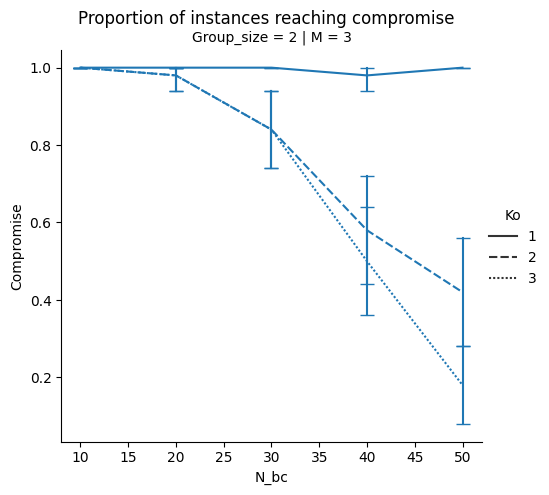

In [61]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Compromise",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise")

Text(0.5, 0.98, 'Computing time for collective model (MILP)')

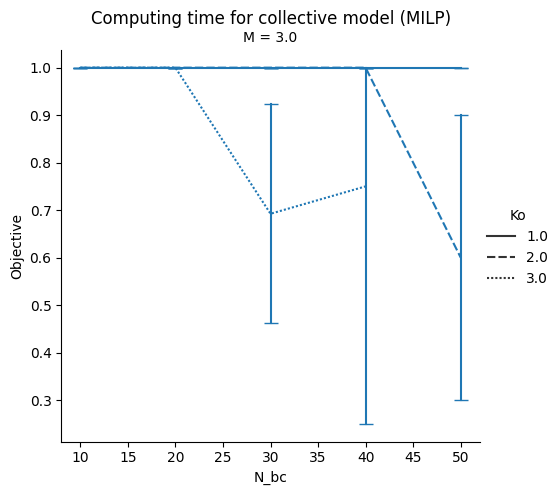

In [48]:
g = sns.relplot(
    df_collective[df_collective["It"] == 1],
    x="N_bc",
    y=df_collective["Objective"] < inf,
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")

In [ ]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")

Text(0.5, 0.98, 'Computing time for preference path')

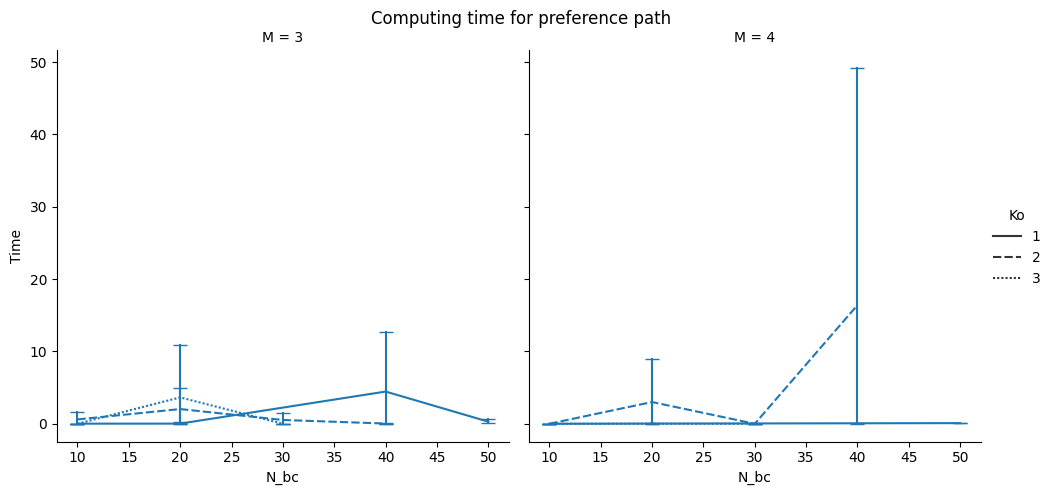

In [36]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for preference path")

Text(0.5, 0.98, 'Number of iterations')

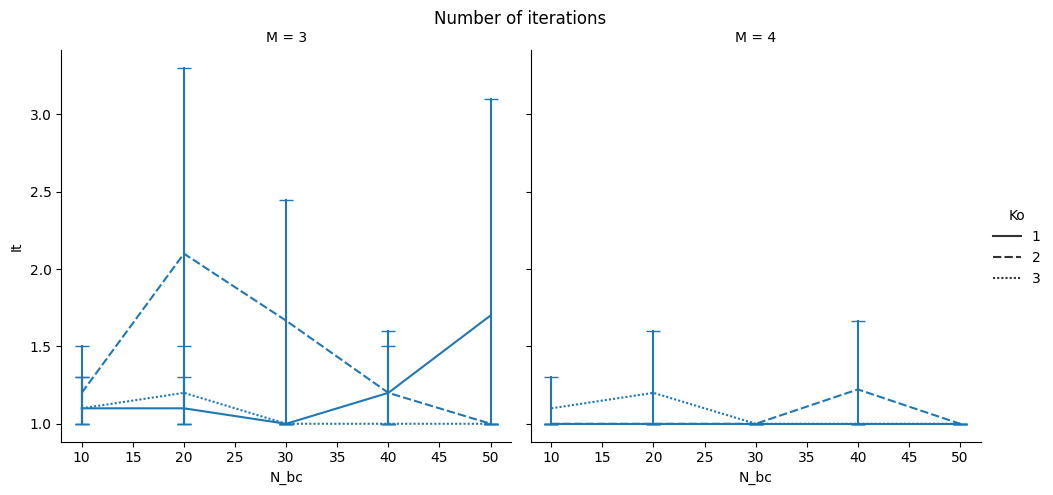

In [24]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="It",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")

Text(0.5, 0.98, 'Max number of comparisons to change for DMs')

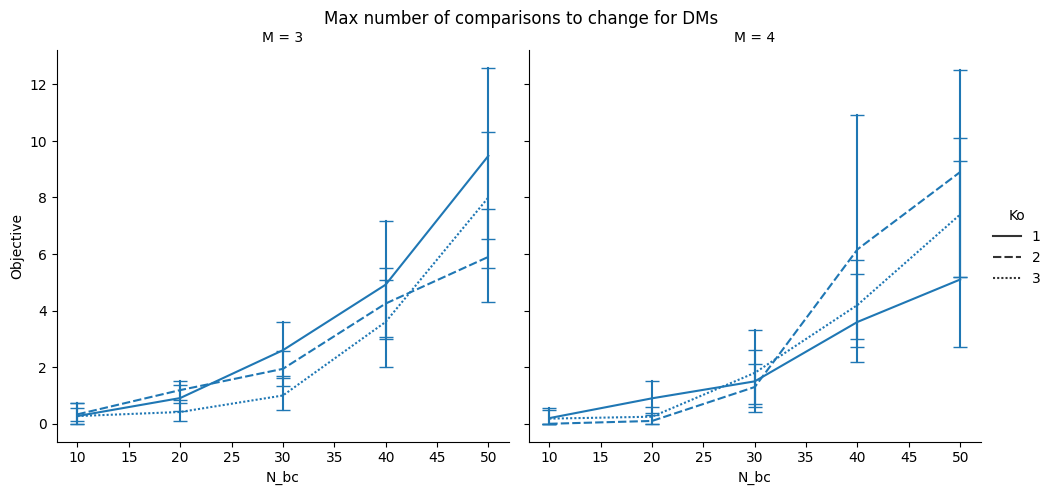

In [37]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")

Text(0.5, 0.98, 'Max proportion of comparisons to change for DMs')

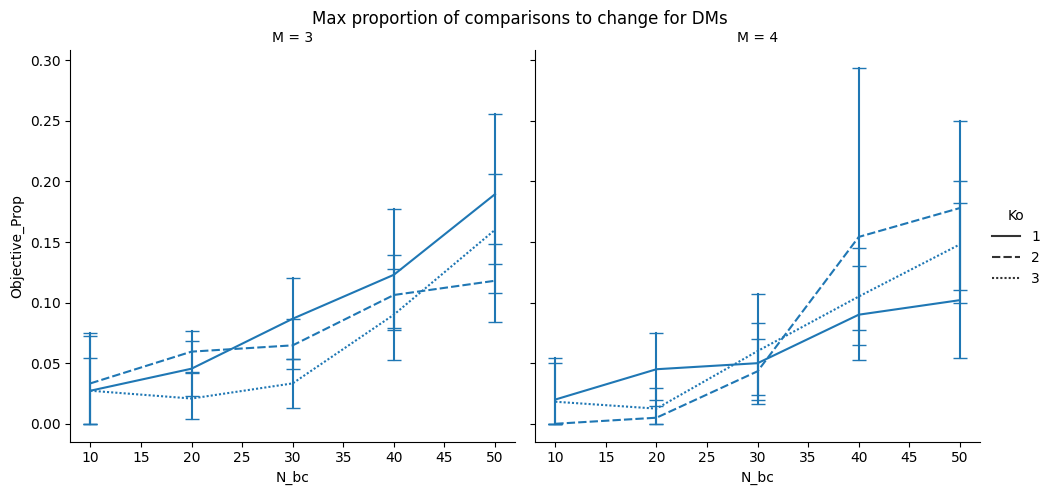

In [31]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective_Prop",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max proportion of comparisons to change for DMs")